**Họ tên:** Chu Thị Bảo Ngọc\
**MSHV:** 22C01035

<hr style="border:1px solid black">

# <h1><center>**BÀI TẬP CUỐI KỲ**</center></h1>
## <h1><center>**Môn: Thị giác máy tính chuyên sâu**</center></h1>
\
<hr style="border:1px solid black">

# Second-level requirement:
### Train and generate images for one class of the dataset using the mechanism of ProGAN.
\
#### **Ghi chú:** Phần code dưới đây đã tham khảo từ nguồn:
https://machinelearningmastery.com/how-to-train-a-progressive-growing-gan-in-keras-for-synthesizing-faces/.

In [1]:
!pip install tensorflow_datasets

# Import libraries
from google.colab import files
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras

from sklearn.model_selection import train_test_split
from skimage.transform import resize
from matplotlib import pyplot as plt
from math import sqrt, ceil
from keras import Model
from keras import utils
from keras import callbacks
from keras import optimizers
from keras import backend
from keras.initializers import RandomNormal
from keras.constraints import max_norm
from keras.datasets import cifar10
from keras.optimizers.legacy import Adam, SGD
from keras.models import Sequential
from keras.layers import Add, Layer, Input, Activation, Conv2D, MaxPooling2D, Conv2DTranspose, UpSampling2D, LeakyReLU, Reshape, Dropout, BatchNormalization, GlobalMaxPooling2D, AveragePooling2D, Flatten, Dense

In [2]:
# Get the full dataset (batch_size=-1) in NumPy arrays from the returned tf.Tensor object
cifar10_train = tfds.load(name="cifar10", split=tfds.Split.TRAIN, batch_size=-1 )
cifar10_test = tfds.load(name="cifar10", split=tfds.Split.TEST, batch_size=-1)

# Convert tfds dataset to numpy array records
cifar10_train = tfds.as_numpy(cifar10_train)
cifar10_test = tfds.as_numpy(cifar10_test)

# Seperate feature X and label Y
X_train, y_train = cifar10_train["image"], cifar10_train["label"]
X_test, y_test = cifar10_test["image"], cifar10_test["label"]

# Print shapes of the entire training and test set of CIFAR 10
print("X_train shape: " + str(X_train.shape))
print("X_test shape: " + str(X_test.shape))
print("y_train shape: " + str(y_train.shape))
print("y_test shape: " + str(y_test.shape))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/3.0.2.incompleteTBL1WV/cifar10-train.tfrecord*...:   0%|          …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/3.0.2.incompleteTBL1WV/cifar10-test.tfrecord*...:   0%|          |…

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000,)
y_test shape: (10000,)


In [3]:
# Get samples  of a certain label. You can choose from one of the classes:
# 0 - airplane; 1 - automobile; 2 - bird; 3 - cat; 4 - deer; 5 - dog; 6 - frog; 7 - horse; 8 - ship; 9 - truck

label = 2                                   # Class '2' is bird
train_indices = np.where(y_train == label)  # Get indices of the label
train_set = X_train[train_indices]          # Get train samples of the label
test_indices = np.where(y_test == label)    # Get indices of the label
test_set = X_test[test_indices]             # Get test samples of the label

# Print shapes of datasets of the selected class
print("Train_set shape of the selected class: " + str(train_set.shape))
print("Test_set shape of the selected class: " + str(test_set.shape))

# NOTE: Training a GAN doesn't require to have train/test split. You should merge the train_set and test_set into one dataset, which can be used as real data samples
data = np.vstack((train_set, test_set))
print("Dataset shape of the selected class: " + str(data.shape))

Train_set shape of the selected class: (5000, 32, 32, 3)
Test_set shape of the selected class: (1000, 32, 32, 3)
Dataset shape of the selected class: (6000, 32, 32, 3)


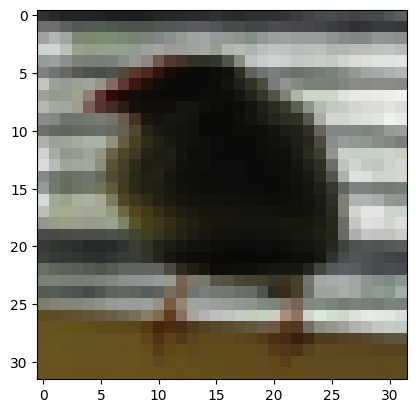

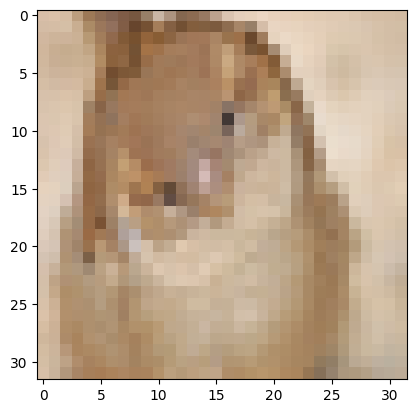

In [4]:
# Visualize some data samples of class '2' (bird)
import matplotlib.pyplot as plt
imgplot = plt.imshow(data[50])
plt.show()
imgplot = plt.imshow(data[5500])
plt.show()

In [5]:
# Weighted sum layer
class WeightedSum(Add):
 # Init with the default value
 def __init__(self, alpha=0.0, **kwargs):
  super(WeightedSum, self).__init__(**kwargs)
  self.alpha = backend.variable(alpha, name='ws_alpha')

 # Outputs weighted sum of inputs
 def _merge_function(self, inputs):
  # Supports weighted sum of only two inputs
  assert (len(inputs) == 2)

  # ((1-a) * input1) + (a * input2)
  output = ((1.0 - self.alpha) * inputs[0]) + (self.alpha * inputs[1])
  return output

# Build the Generator

In [6]:
# Add a generator block
def add_generator_block(old_model):
  # Getting the end of the last block
  block_end = old_model.layers[-2].output

  # Upsampling, and defining new block
  upsampling = UpSampling2D()(block_end)
  g = Conv2D(128, (3,3), padding='same')(upsampling)
  g = LeakyReLU(alpha=0.2)(g)

  g = Conv2D(64, (3,3), padding='same')(g)
  g = LeakyReLU(alpha=0.2)(g)

  # Adding new output layer
  out_image = Conv2D(3, (1,1), padding='same')(g)

  # Defining model
  model1 = Model(old_model.input, out_image)

  # Getting the output layer from old model
  out_old = old_model.layers[-1]

  # Connecting the upsample to the old output layer
  out_image2 = out_old(upsampling)

  # Defining new output image as the weighted sum of the old and new models
  merged = WeightedSum()([out_image2, out_image])

  # Defining model
  model2 = Model(old_model.input, merged)

  return [model1, model2]

In [7]:
# Defining generator models
def define_generator(latent_dim, n_blocks, in_dim=4):
  model_list = list()

  # Base model latent input
  in_latent = Input(shape=(latent_dim,))

  # Linearly scaling up to activation maps
  g = Dense(256 * in_dim * in_dim)(in_latent)
  g = Reshape((in_dim, in_dim, 256))(g)

  # Conv 3x3, input block
  g = Conv2D(128, (3,3), padding='same')(g)
  g = LeakyReLU(alpha=0.2)(g)

  # Conv 3x3
  g = Conv2D(64, (3,3), padding='same')(g)
  g = LeakyReLU(alpha=0.2)(g)

  # Conv 1x1, output block
  out_image = Conv2D(3, (1,1), activation='tanh', padding='same')(g)

  # Defining model
  model = Model(in_latent, out_image)

  # Storing model
  model_list.append([model, model])

  # Creating submodels
  for i in range(1, n_blocks):
    # Getting prior model without the fade-on
    old_model = model_list[i - 1][0]

    # Creating new model for next resolution
    models = add_generator_block(old_model)

    # Storing model
    model_list.append(models)

  return model_list

# Show the fade-in version of the fourth Generator model, which has output resolution of 32x32
generators = define_generator(256, 4)
generators[3][1].summary()

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256)]                0         []                            
                                                                                                  
 dense (Dense)               (None, 4096)                 1052672   ['input_1[0][0]']             
                                                                                                  
 reshape (Reshape)           (None, 4, 4, 256)            0         ['dense[0][0]']               
                                                                                                  
 conv2d (Conv2D)             (None, 4, 4, 128)            295040    ['reshape[0][0]']             
                                                                                            

# Build the Discriminator

In [8]:
# Add a discriminator block
def add_discriminator_block(old_model, n_input_layers=3):
  # Getting shape of existing model
  in_shape = list(old_model.input.shape)

  # Defining new input shape as double the size
  i_s = (int(in_shape[-2])*2, int(in_shape[-2])*2, int(in_shape[-1]))
  in_img = Input(shape=i_s)

  # Defining new input processing layer
  d = Conv2D(64, (1,1), padding='same')(in_img)
  d = LeakyReLU(alpha=0.2)(d)

  # Defining new block
  d = Conv2D(128, (3,3), padding='same')(d)
  d = LeakyReLU(alpha=0.2)(d)

  d = Conv2D(64, (3,3), padding='same')(d)
  d = LeakyReLU(alpha=0.2)(d)

  d = AveragePooling2D()(d)
  block_new = d

  # Skipping the input
  for i in range(n_input_layers, len(old_model.layers)):
    d = old_model.layers[i](d)

  # Defining straight-through model
  m1 = Model(in_img, d)

  # Compiling model
  opt = Adam(learning_rate=0.0001, beta_1=0.5)
  m1.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

  # Downsampling the new larger image
  downsample = AveragePooling2D()(in_img)

  # Connecting old input
  block_old = old_model.layers[1](downsample)
  block_old = old_model.layers[2](block_old)

  # Fade in output of old model input layer with new input
  d = WeightedSum()([block_old, block_new])

  # Skipping the input
  for i in range(n_input_layers, len(old_model.layers)):
    d = old_model.layers[i](d)

  # Defining straight-through model
  m2 = Model(in_img, d)

  # Compiling model
  m2.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

  return [m1, m2]

In [9]:
# Define the discriminator models for each image resolution
def define_discriminator(n_blocks, input_shape=(4,4,3)):
  model_list = list()

  # Base model input
  in_image = Input(shape=input_shape)

  # Conv 1x1
  d = Conv2D(64, (1,1), padding='same')(in_image)
  d = LeakyReLU(alpha=0.2)(d)

  # Conv 3x3 (output block)
  d = Conv2D(128, (3,3), padding='same')(d)
  d = LeakyReLU(alpha=0.2)(d)

  # Conv 3x3
  d = Conv2D(256, (3,3), padding='same')(d)
  d = LeakyReLU(alpha=0.2)(d)

  # Dense output layer
  d = Flatten()(d)
  d = Dropout(0.5)(d)
  out_class = Dense(1, activation='sigmoid')(d)

  # Define model
  model = Model(in_image, out_class)

  # Compile model
  opt = Adam(learning_rate=0.0001, beta_1=0.5)
  model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

  # Store model
  model_list.append([model, model])

  # Create submodels
  for i in range(1, n_blocks):
    # Get prior model without the fade-on
    old_model = model_list[i - 1][0]

    # Create new model for next resolution
    models = add_discriminator_block(old_model)

    # Store model
    model_list.append(models)

  return model_list

# Show the fade-in version of the fourth Discriminator model, which has input resolution of 32x32
discriminators = define_discriminator(4)
discriminators[3][1].summary()

Model: "model_13"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv2d_21 (Conv2D)          (None, 32, 32, 64)           256       ['input_5[0][0]']             
                                                                                                  
 leaky_re_lu_17 (LeakyReLU)  (None, 32, 32, 64)           0         ['conv2d_21[0][0]']           
                                                                                                  
 conv2d_22 (Conv2D)          (None, 32, 32, 128)          73856     ['leaky_re_lu_17[0][0]']      
                                                                                           

# Build composite models for training Generators via Discriminators

In [10]:
# Define composite models for training generators via discriminators
def define_composite(discriminators, generators):
  model_list = list()

  # Creating composite models
  for i in range(len(discriminators)):
    g_models, d_models = generators[i], discriminators[i]

    # Straight-through model
    d_models[0].trainable = False
    model1 = Sequential()
    model1.add(g_models[0])
    model1.add(d_models[0])
    opt = Adam(learning_rate=0.0001, beta_1=0.5)
    model1.compile(loss='binary_crossentropy', optimizer=opt)

    # Fade-in model
    d_models[1].trainable = False
    model2 = Sequential()
    model2.add(g_models[1])
    model2.add(d_models[1])
    model2.compile(loss='binary_crossentropy', optimizer=opt)

    # Storing
    model_list.append([model1, model2])

  return model_list

In [11]:
# Update the alpha value on each instance of WeightedSum
def update_fadein(models, step, n_steps):
  # Calculate current alpha (linear from 0 to 1)
  alpha = step / float(n_steps - 1)

  # Update the alpha for each model
  for model in models:
    for layer in model.layers:
      if isinstance(layer, WeightedSum):
        backend.set_value(layer.alpha, alpha)

In [12]:
# Scale images to preferred size
def scale_dataset(images, new_shape):
  images_list = list()
  for image in images:
    # Resize with nearest neighbor interpolation
    new_image = resize(image, new_shape, 0)

    # Storing
    images_list.append(new_image)

  return np.asarray(images_list)

# Prepare real data samples from the CIFAR 10 dataset

In [13]:
# Load and normalize CIFAR 10 images of the selected class
def load_real_samples():
  # Load dataset
  (X_train, y_train), (X_test, y_test) = cifar10.load_data()
  label = 2                                      # Class '2' is bird
  train_indices = np.where(y_train == label)[0]  # Get indices of the label
  train_set = X_train[train_indices]
  test_indices = np.where(y_test == label)[0]    # Get indices of the label
  test_set = X_test[test_indices]
  X = np.vstack((train_set, test_set))

  # Convert pixel values from unsigned int to float32 for normalization calculation
  X = X.astype('float32')

  # Because the generator is using tanh activation, we need to normalize real images from range [0,255] to range [-1,1]
  X = (X - 127.5) / 127.5

  return X  # Return the set of normalized images

# Select real samples from the real dataset for training purpose
def generate_real_samples(dataset, n_samples):
  # Generate random n_samples sample indices from the dataset
  ix = np.random.randint(0, dataset.shape[0], size = n_samples)

  # Get the images from the list of indices
  X = dataset[ix]

  # Generate labels for the real samples (label=1)
  y = np.ones((n_samples, 1))

  return X, y  # Return the real images and labels

# Generate fake data samples by passing a random vector through the Generator

In [14]:
# Generate random latent vectors as input for Generator
def generate_latent_points(latent_dim, n_samples):
  # Generate points in the latent space
  x_input = np.random.randn(latent_dim * n_samples)

  # Reshape to a batch of inputs for the Generator
  x_input = x_input.reshape(n_samples, latent_dim)

  return x_input

# Use Generator to generate n_samples fake samples
def generate_fake_samples(g_model, latent_dim, n_samples):
  # Generate random latent vectors as input for Generator
  x_input = generate_latent_points(latent_dim, n_samples)

  # Generate fake data samples by passing the random latent vectors through the Generator
  X = g_model.predict(x_input)

  # Generate labels for the fake samples (label=0)
  y = np.zeros((n_samples, 1))

  return X, y  # Return the fake images and labels

# Save the Generator's outputs and the models

In [15]:
# Generating samples, saving as a plot and saving the model
def summarize_performance(status, g_model, d_model, gan_model, latent_dim, n_samples=49):

  # Devising a name
  gs = g_model.output_shape
  nm = '%03dx%03d-%s' % (gs[1], gs[2], status)

  # Generating images
  X, _ = generate_fake_samples(g_model, latent_dim, n_samples)

	# Plotting real images
  square = int(sqrt(n_samples))
  for i in range(n_samples):
    plt.subplot(square, square, 1 + i)
    plt.axis('off')
    plt.imshow(((X[i] * 127.5) + 127.5).astype(np.uint8))  # Convert pixel values from range [-1,1] into range [0,255]

  # Saving a plot to file
  f1 = 'plot_%s.png' % (nm)
  plt.savefig(f1)
  plt.close()

  # Saving the generator model
  f2 = 'g_model_%s.sav' % (nm)
  g_model.save(f2)

  # Saving the discriminator model
  f3 = 'd_model_%s.sav' % (nm)
  d_model.save(f3)

  # Saving the composite model
  f4 = 'gan_model_%s.sav' % (nm)
  gan_model.save(f4)

  print('>Saved: %s, %s, %s and %s' % (f1, f2, f3, f4))

# Training process with the Generator and the Discriminator

In [16]:
# Train a Generator and a Discriminator
def train_epochs(g_model, d_model, gan_model, dataset, latent_dim, n_epochs, n_batch, fadein=False):
  bat_per_epo = int(dataset.shape[0] / n_batch)  # Number of iterations per epoch
  half_batch = int(n_batch / 2)                  # A batch to the Discriminator contains real samples (half-batch) and fake samples (half-batch)
  n_steps = bat_per_epo * n_epochs               # Calculate the number of training iterations

  g_loss_values = []                                  # Array containing Generator loss over iterations
  d_loss_real_values = []                             # Array containing Discriminator loss of real samlples over iterations
  d_loss_fake_values = []                             # Array containing Discriminator loss of fake samlples over iterations

  # Manually enumerating epochs
  for x in range(n_steps):
    # Updating alpha for all WeightedSum layers when fading in new blocks
    if fadein:
      update_fadein([g_model, d_model, gan_model], x, n_steps)

  	# Preparing real and fake samples
    X_real, y_real = generate_real_samples(dataset, half_batch)
    X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)

    # Updating discriminator model
    d_loss1, _ = d_model.train_on_batch(X_real, y_real)
    d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)

  	# Updating the generator via the discriminator's error
    X_gan = generate_latent_points(latent_dim, n_batch)
    y_gan = np.ones((n_batch, 1))
    g_loss = gan_model.train_on_batch(X_gan, y_gan)

  	# Summarizing loss on this batch
    i = ceil((x + 1) / bat_per_epo)            # Calculate the current epoch
    k = (i - 1) * bat_per_epo                  # Calculate the iterations in the previous epochs
    j = x + 1 - k                              # Calculate the current iteration in the current epoch
    print('Epoch %d, Iteration %d/%d, D_loss_real = %.3f, D_loss_fake = %.3f, G_loss = %.3f' % (i, j, bat_per_epo, d_loss1, d_loss2, g_loss))

    # Add loss values to historical arrays
    g_loss_values.append(g_loss)
    d_loss_real_values.append(d_loss1)
    d_loss_fake_values.append(d_loss2)

  return d_loss_real_values, d_loss_fake_values, g_loss_values          # Return the loss arrays of Generator and Discriminator

In [17]:
# Train the Generators and the Discriminators
def train(g_models, d_models, gan_models, dataset, latent_dim, e_norm, e_fadein, n_batch):
  # Fitting the baseline model
  gn, dn, gan_n = g_models[0][0], d_models[0][0], gan_models[0][0]

	# Scaling dataset to appropriate size
  gs = gn.output_shape
  sd = scale_dataset(dataset, gs[1:])
  print('Scaled Data', sd.shape)

  # Training normal or straight-through models
  train_epochs(gn, dn, gan_n, sd, latent_dim, e_norm[0], n_batch[0])
  summarize_performance('tuned', gn, dn, gan_n, latent_dim)

	# Processing each level of growth
  for i in range(1, len(g_models)):
    # Retrieving models for this level of growth
    [gn, g_fadein] = g_models[i]
    [dn, d_fadein] = d_models[i]
    [gan_n, gan_fadein] = gan_models[i]

  	# Scaling the dataset to appropriate size
    gs = gn.output_shape
    sd = scale_dataset(dataset, gs[1:])
    print('Scaled Data', sd.shape)

  	# Training fade-in models for next level of growth
    d_losses_real_fadein, d_losses_fake_fadein, g_losses_fadein = train_epochs(g_fadein, d_fadein, gan_fadein, sd, latent_dim, e_fadein[i], n_batch[i], True)
    summarize_performance('faded', g_fadein, d_fadein, gan_fadein, latent_dim)
    # -> During the fade-in phase, a portion of the generator and discriminator operates at a lower resolution while the newly introduced layers are gradually scaled up.
    # This phase is designed to ease the transition from one resolution to another, by helping to reduce the risk of instability when moving to higher resolutions.

  	# Training normal or straight-through models
    d_losses_real_norm, d_losses_fake_norm, g_losses_norm = train_epochs(gn, dn, gan_n, sd, latent_dim, e_norm[i], n_batch[i])
    summarize_performance('tuned', gn, dn, gan_n, latent_dim)

  # Return the losses of the last level of growth (32x32 resolution)
  return d_losses_real_fadein, d_losses_fake_fadein, g_losses_fadein, d_losses_real_norm, d_losses_fake_norm, g_losses_norm

# Main code

In [18]:
# Size of the latent space
latent_dim = 256
n_blocks = 4      # Number of growth phases. For example, 4 == [4, 8, 16, 32]
epochs = [30, 40, 50, 60]
batch_size = [128, 128, 128, 128]

# Create the models
g_models = define_generator(latent_dim, n_blocks)
d_models = define_discriminator(n_blocks)
gan_models = define_composite(d_models, g_models)

# loading image data
dataset = load_real_samples()

# Train the ProGAN
d_losses_real_fadein, d_losses_fake_fadein, g_losses_fadein, d_losses_real_norm, d_losses_fake_norm, g_losses_norm = train(g_models, d_models, gan_models, dataset, latent_dim, epochs, epochs, batch_size)

170498071/170498071 [==============================] - 4s 0us/step
Scaled Data (6000, 4, 4, 3)
2/2 [==============================] - 1s 4ms/step
Epoch 1, Iteration 1/46, D_loss_real = 0.692, D_loss_fake = 0.699, G_loss = 0.694
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 2/46, D_loss_real = 0.683, D_loss_fake = 0.698, G_loss = 0.695
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 3/46, D_loss_real = 0.677, D_loss_fake = 0.697, G_loss = 0.691
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 4/46, D_loss_real = 0.665, D_loss_fake = 0.700, G_loss = 0.687
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 5/46, D_loss_real = 0.653, D_loss_fake = 0.711, G_loss = 0.679
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 6/46, D_loss_real = 0.637, D_loss_fake = 0.724, G_loss = 0.669
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 7/46, D_loss_real = 0.636, D_loss_fak

>Saved: plot_004x004-tuned.png, g_model_004x004-tuned.sav, d_model_004x004-tuned.sav and gan_model_004x004-tuned.sav
Scaled Data (6000, 8, 8, 3)
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 1/46, D_loss_real = 0.700, D_loss_fake = 0.698, G_loss = 0.690
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 2/46, D_loss_real = 0.688, D_loss_fake = 0.703, G_loss = 0.691
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 3/46, D_loss_real = 0.683, D_loss_fake = 0.701, G_loss = 0.687
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 4/46, D_loss_real = 0.684, D_loss_fake = 0.707, G_loss = 0.688
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 5/46, D_loss_real = 0.676, D_loss_fake = 0.704, G_loss = 0.689
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 6/46, D_loss_real = 0.669, D_loss_fake = 0.698, G_loss = 0.690
2/2 [==============================] - 0s 3ms/step
Epoch 

>Saved: plot_008x008-faded.png, g_model_008x008-faded.sav, d_model_008x008-faded.sav and gan_model_008x008-faded.sav
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 1/46, D_loss_real = 0.660, D_loss_fake = 0.707, G_loss = 0.684
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 2/46, D_loss_real = 0.665, D_loss_fake = 0.732, G_loss = 0.671
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 3/46, D_loss_real = 0.646, D_loss_fake = 0.764, G_loss = 0.656
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 4/46, D_loss_real = 0.655, D_loss_fake = 0.793, G_loss = 0.651
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 5/46, D_loss_real = 0.673, D_loss_fake = 0.791, G_loss = 0.656
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 6/46, D_loss_real = 0.687, D_loss_fake = 0.727, G_loss = 0.707
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 7/46, D_loss_re

>Saved: plot_008x008-tuned.png, g_model_008x008-tuned.sav, d_model_008x008-tuned.sav and gan_model_008x008-tuned.sav
Scaled Data (6000, 16, 16, 3)
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 1/46, D_loss_real = 0.705, D_loss_fake = 0.679, G_loss = 0.705
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 2/46, D_loss_real = 0.693, D_loss_fake = 0.686, G_loss = 0.705
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 3/46, D_loss_real = 0.695, D_loss_fake = 0.688, G_loss = 0.704
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 4/46, D_loss_real = 0.691, D_loss_fake = 0.688, G_loss = 0.703
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 5/46, D_loss_real = 0.688, D_loss_fake = 0.685, G_loss = 0.698
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 6/46, D_loss_real = 0.678, D_loss_fake = 0.689, G_loss = 0.697
2/2 [==============================] - 0s 3ms/step
Epoc

>Saved: plot_016x016-faded.png, g_model_016x016-faded.sav, d_model_016x016-faded.sav and gan_model_016x016-faded.sav
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 1/46, D_loss_real = 0.709, D_loss_fake = 0.646, G_loss = 0.781
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 2/46, D_loss_real = 0.712, D_loss_fake = 0.645, G_loss = 0.772
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 3/46, D_loss_real = 0.706, D_loss_fake = 0.644, G_loss = 0.758
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 4/46, D_loss_real = 0.705, D_loss_fake = 0.671, G_loss = 0.741
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 5/46, D_loss_real = 0.702, D_loss_fake = 0.661, G_loss = 0.728
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 6/46, D_loss_real = 0.693, D_loss_fake = 0.679, G_loss = 0.727
2/2 [==============================] - 0s 3ms/step
Epoch 1, Iteration 7/46, D_loss_re

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 32/46, D_loss_real = 0.656, D_loss_fake = 0.725, G_loss = 0.711
2/2 [==============================] - 0s 3ms/step
Epoch 6, Iteration 33/46, D_loss_real = 0.618, D_loss_fake = 0.723, G_loss = 0.723
2/2 [==============================] - 0s 3ms/step
Epoch 6, Iteration 34/46, D_loss_real = 0.614, D_loss_fake = 0.771, G_loss = 0.752
2/2 [==============================] - 0s 3ms/step
Epoch 6, Iteration 35/46, D_loss_real = 0.636, D_loss_fake = 0.714, G_loss = 0.757
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 36/46, D_loss_real = 0.664, D_loss_fake = 0.686, G_loss = 0.762
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 37/46, D_loss_real = 0.669, D_loss_fake = 0.678, G_loss = 0.798
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 38/46, D_loss_real = 0.671, D_loss_fake = 0.645, G_loss = 0.790
2/2 [

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 32/46, D_loss_real = 0.640, D_loss_fake = 0.740, G_loss = 0.774
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 33/46, D_loss_real = 0.686, D_loss_fake = 0.682, G_loss = 0.772
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 34/46, D_loss_real = 0.685, D_loss_fake = 0.643, G_loss = 0.767
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 35/46, D_loss_real = 0.628, D_loss_fake = 0.745, G_loss = 0.760
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 36/46, D_loss_real = 0.668, D_loss_fake = 0.714, G_loss = 0.776
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 37/46, D_loss_real = 0.679, D_loss_fake = 0.700, G_loss = 0.782
2/2 [==============================] - 0s 4ms/step
Epoch 6, Iteration 38/46, D_loss_real = 0.684, D_loss_fake = 0.686, G_loss = 0.775
2/2 [

>Saved: plot_032x032-tuned.png, g_model_032x032-tuned.sav, d_model_032x032-tuned.sav and gan_model_032x032-tuned.sav


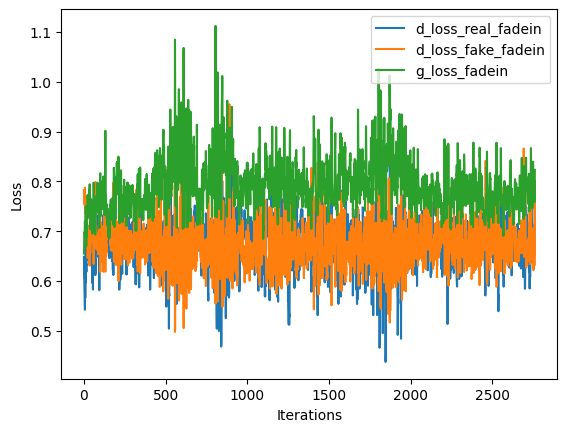

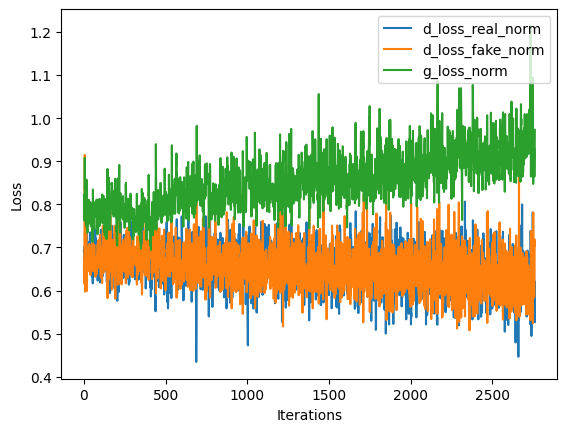

In [19]:
### Plot the training loss of the Generator and the Discriminator of the last level of growth (32x32 resolution) over iterations

# Initialize values of x-axis (iterations)
gx_fadein = np.linspace(0, len(g_losses_fadein), len(g_losses_fadein))
dx_real_fadein = np.linspace(0, len(d_losses_real_fadein), len(d_losses_real_fadein))
dx_fake_fadein = np.linspace(0, len(d_losses_fake_fadein), len(d_losses_fake_fadein))

gx_norm = np.linspace(0, len(g_losses_norm), len(g_losses_norm))
dx_real_norm = np.linspace(0, len(d_losses_real_norm), len(d_losses_real_norm))
dx_fake_norm = np.linspace(0, len(d_losses_fake_norm), len(d_losses_fake_norm))

# Plot the training loss of G and D
plt.plot(dx_real_fadein, d_losses_real_fadein)
plt.plot(dx_fake_fadein, d_losses_fake_fadein)
plt.plot(gx_fadein, g_losses_fadein)
plt.ylabel('Loss')
plt.xlabel('Iterations')
plt.legend(['d_loss_real_fadein', 'd_loss_fake_fadein', 'g_loss_fadein'], loc='upper right')
plt.show()

plt.plot(dx_real_norm, d_losses_real_norm)
plt.plot(dx_fake_norm, d_losses_fake_norm)
plt.plot(gx_norm, g_losses_norm)
plt.ylabel('Loss')
plt.xlabel('Iterations')
plt.legend(['d_loss_real_norm', 'd_loss_fake_norm', 'g_loss_norm'], loc='upper right')
plt.show()

# Load the models

In [20]:
# Load the Generator from the final saved model
g_model = keras.models.load_model("g_model_032x032-tuned.sav", custom_objects={"WeightedSum": WeightedSum})

# Generate 49 fake images by passing 256-dimensional random vectors through the Generator
X_fake, _ = generate_fake_samples(g_model, 256, 49)

2/2 [==============================] - 0s 4ms/step


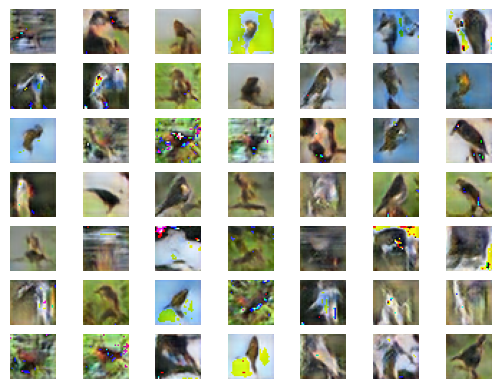

In [21]:
# Visualize all generated images
for i in range(49):
  plt.subplot(7, 7, 1 + i)
  plt.axis('off')
  plt.imshow(((X_fake[i] * 127.5) + 127.5).astype(np.uint8))  # Convert pixel values from range [-1,1] into range [0,255]
plt.show()

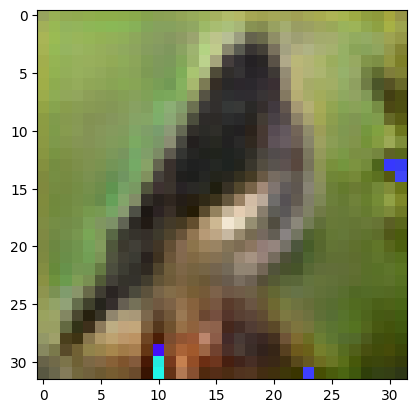

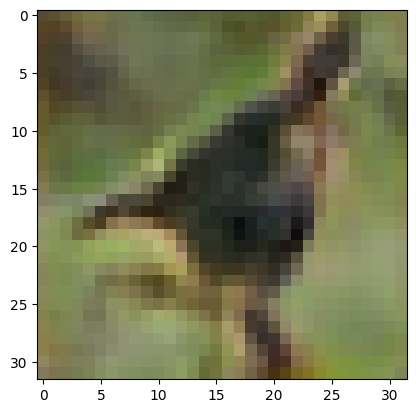

In [31]:
# Visualize some individual generated images
imgplot = plt.imshow(((X_fake[26] * 127.5) + 127.5).astype(np.uint8))
plt.show()
imgplot = plt.imshow(((X_fake[48] * 127.5) + 127.5).astype(np.uint8))
plt.show()

In [23]:
# Compress output folders for downloading
!zip -r /content/g_model_032x032-tuned.zip /content/g_model_032x032-tuned.sav
!zip -r /content/d_model_032x032-tuned.zip /content/d_model_032x032-tuned.sav
!zip -r /content/gan_model_032x032-tuned.zip /content/gan_model_032x032-tuned.sav

  adding: content/g_model_032x032-tuned.sav/ (stored 0%)
  adding: content/g_model_032x032-tuned.sav/assets/ (stored 0%)
  adding: content/g_model_032x032-tuned.sav/fingerprint.pb (stored 0%)
  adding: content/g_model_032x032-tuned.sav/keras_metadata.pb (deflated 94%)
  adding: content/g_model_032x032-tuned.sav/saved_model.pb (deflated 90%)
  adding: content/g_model_032x032-tuned.sav/variables/ (stored 0%)
  adding: content/g_model_032x032-tuned.sav/variables/variables.index (deflated 65%)
  adding: content/g_model_032x032-tuned.sav/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: content/d_model_032x032-tuned.sav/ (stored 0%)
  adding: content/d_model_032x032-tuned.sav/assets/ (stored 0%)
  adding: content/d_model_032x032-tuned.sav/fingerprint.pb (stored 0%)
  adding: content/d_model_032x032-tuned.sav/keras_metadata.pb (deflated 94%)
  adding: content/d_model_032x032-tuned.sav/saved_model.pb (deflated 89%)
  adding: content/d_model_032x032-tuned.sav/variables/ (stored 0

In [33]:
# Download the final Generator, Discriminator and composite straight-through model
files.download("/content/g_model_032x032-tuned.zip")
files.download("/content/d_model_032x032-tuned.zip")
files.download("/content/gan_model_032x032-tuned.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>